Task 1:Data Collection & Dataset Understanding

In [2]:
import pandas as pd
df = pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


The Titanic dataset contains information about 891 passengers, including whether they survived, their passenger class, age, family members aboard, and ticket fare. From the statistical summary, around 38% of passengers survived. The average age was approximately 30 years, although some age values are missing. Most passengers were in lower passenger classes, especially 2nd and 3rd class. The fare values show a large variation, meaning ticket prices differed greatly depending on class and passenger type. Overall, this summary helps us understand the general distribution of the numerical features before starting deeper analysis.

Task 2:Data Cleaning & Preprocessing

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Age feature has 177 missing values,Cabin feature has 687 missing values and Embarked feature has 2 missing values 

In [6]:
df['Age']=df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


C:\Users\DELL\AppData\Local\Temp\ipykernel_18856\1657261844.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age']=df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\DELL\AppData\Local\Temp\ipykernel_18856\1657261844.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained 

In the Age column I replaced all the missing values with the median Age value ,which is 28 years old,and in the Embarked column I replaced all the missing values with the mode value 

In [7]:
df.drop('Cabin',axis=1,inplace=True)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

Task 3:Exploratory Data Analysis (EDA)

In [12]:
df['Age'].mean()


np.float64(29.36158249158249)

In [13]:
df['Fare'].mean()

np.float64(32.204207968574636)

In [14]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

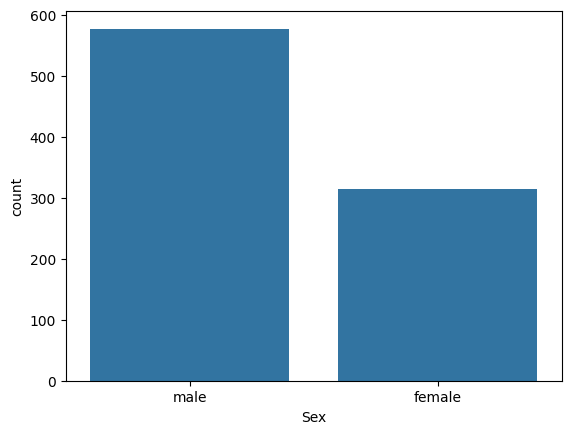

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', data=df)

plt.show()

In [16]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

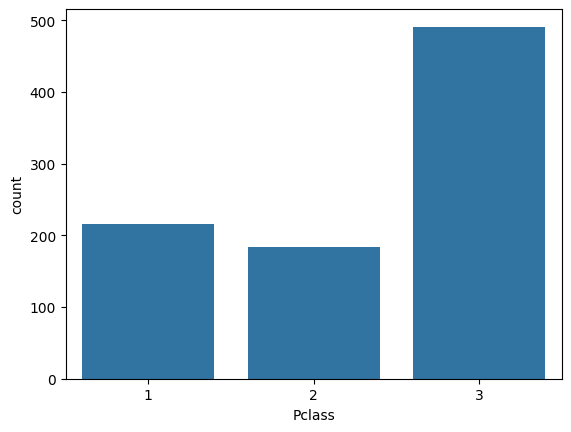

In [17]:
sns.countplot(x='Pclass', data=df)

plt.show()

Class 3,the lowest class,had the most number of passengers

In [10]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

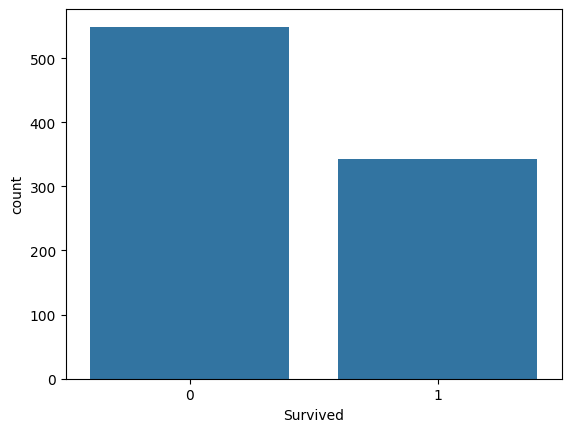

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)

plt.show()

In [18]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

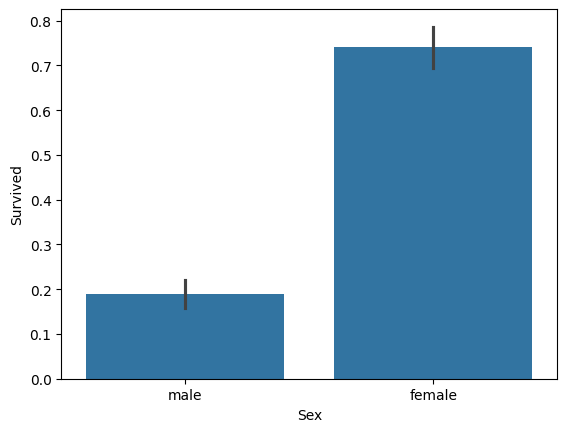

In [19]:
sns.barplot(x='Sex', y='Survived', data=df)

plt.show()

The priority was to save females as most of the females,74% of the females survived and only 19% of the males survived

In [20]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

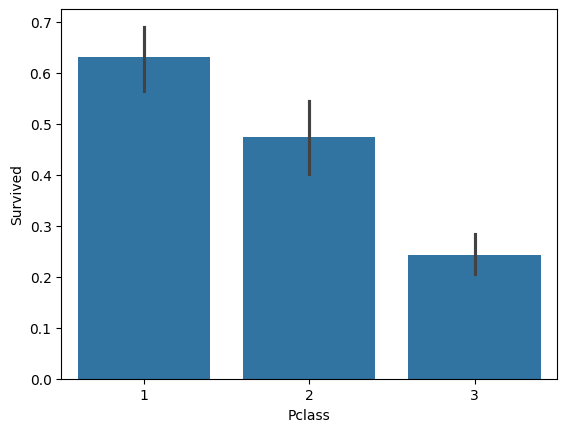

In [21]:
sns.barplot(x='Pclass', y='Survived', data=df)

plt.show()

They prioritized saving passengers in the 1st class more than the others and the 3rd class passengers were the least to survive 

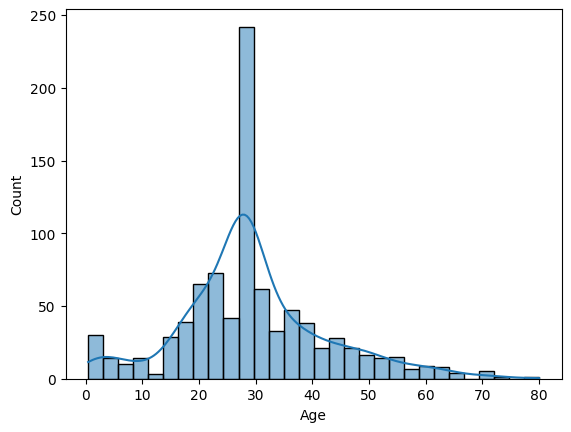

In [22]:
sns.histplot(df['Age'], kde=True)

plt.show()

Normal age distribution, most of the passengers were young adults around 29 years old

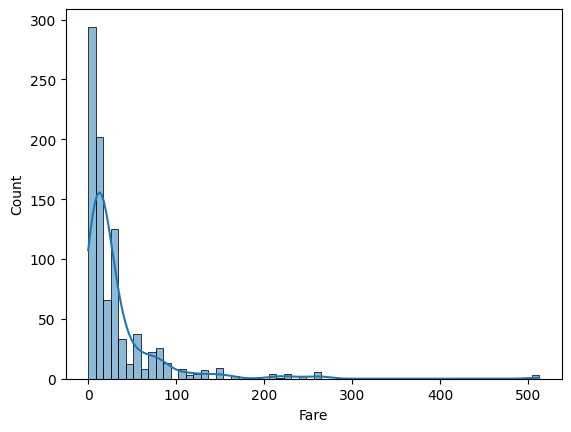

In [23]:
sns.histplot(df['Fare'], kde=True)

plt.show()

Fare's distribution is strongly right-skewed(Positively Skewed),most of the passengers paid low fares as the 2nd and 3rd classes paid small ticket prices and only few passengers ,whom were the 1st class passengers,paid high fares.

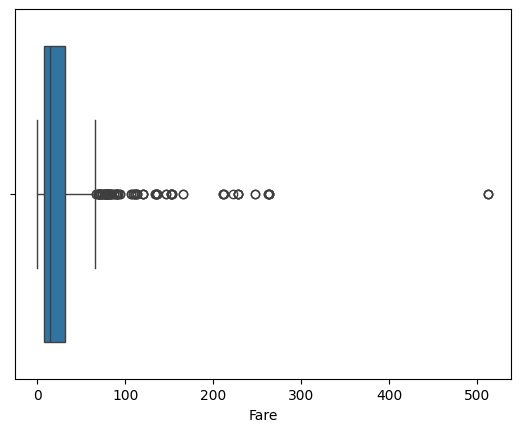

In [24]:
sns.boxplot(x=df['Fare'])

plt.show()

Most of the outliers in fares were 100+ and there were some 200+ but there were one extreme outlier 500+

In [25]:
df['Fare'].skew()

np.float64(4.787316519674893)

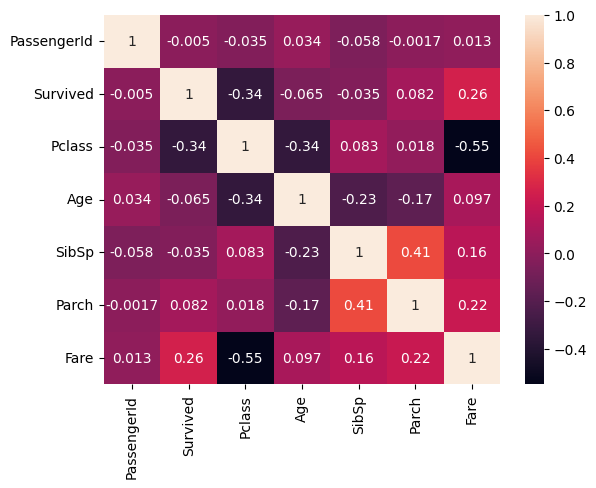

In [26]:
numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.show()

The correlation analysis showed that Fare and Pclass had a strong negative correlation, meaning passengers in higher classes generally paid higher fares. Survival had a positive correlation with Fare and a negative correlation with Pclass, suggesting that wealthier and first-class passengers had better survival chances. SibSp and Parch showed a moderate positive correlation, indicating that passengers traveling with siblings or spouses often traveled with parents or children as well. Most other correlations were weak, showing little direct relationship between those features.
